<a href="https://colab.research.google.com/github/Yukari1907/Aula-05-ES/blob/main/Aula5_ES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parte 1: Diagrama no Miro e Draw.io
Atores: Leitor, Bibliotecário, Sistema de Pagamento

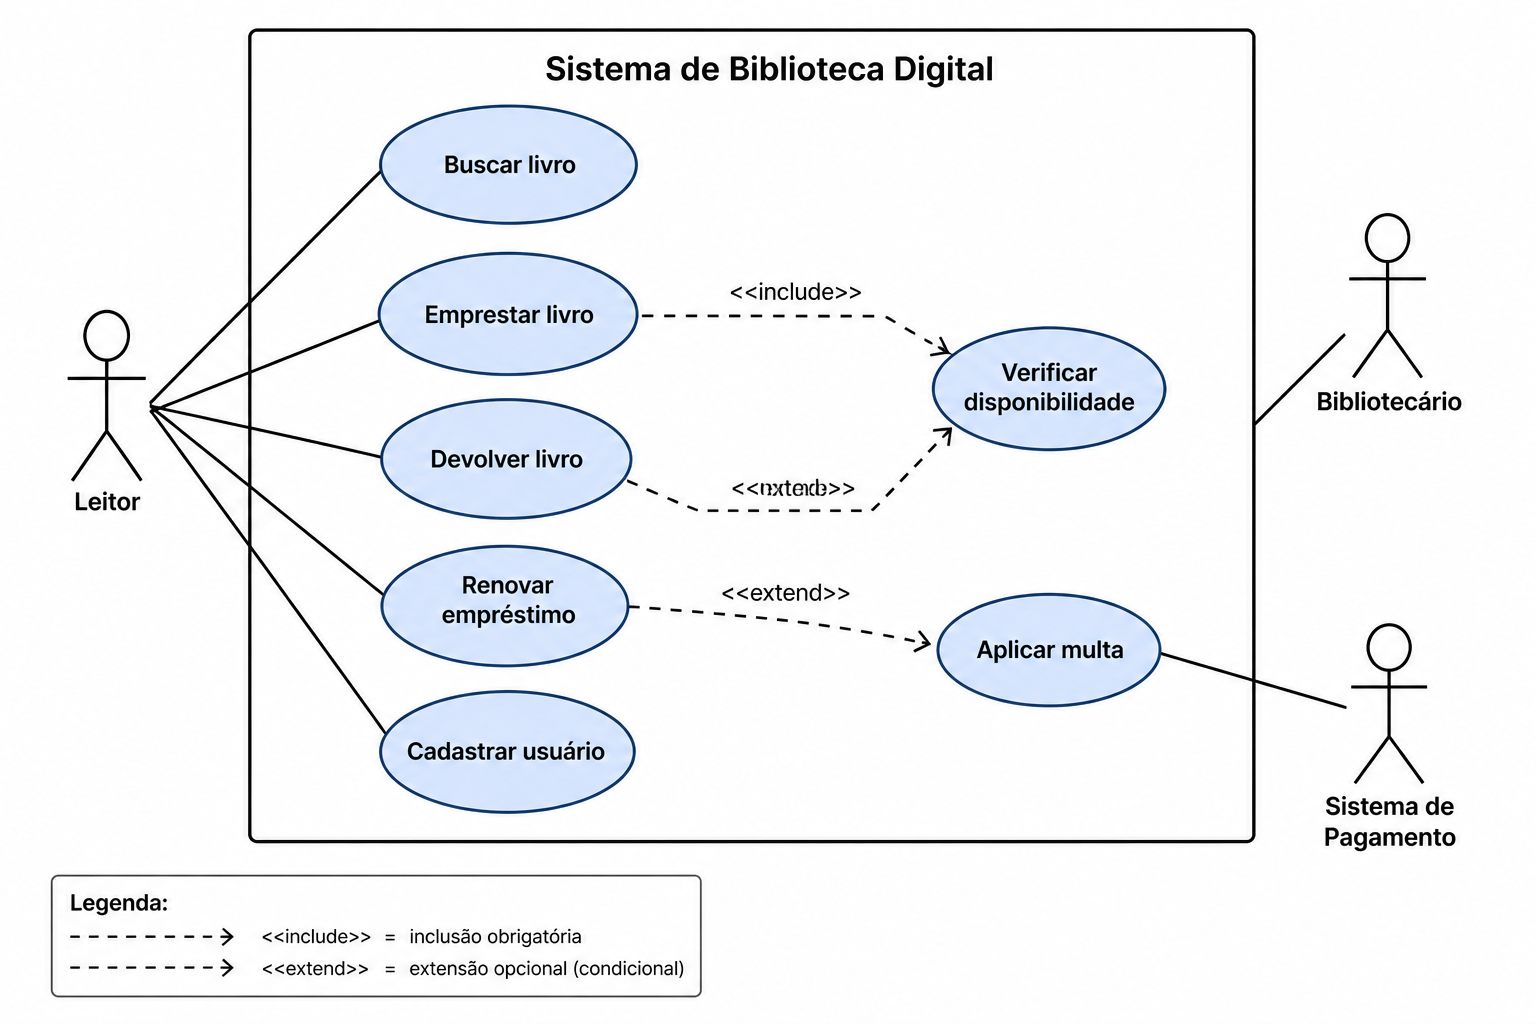

# Parte 2: Especificação

UC-02: Emprestar Livro

Ator: Leitor

Pré-condições:

- Usuário cadastrado
- Livro existe no catálogo

Fluxo Principal:

1.   O leitor informa o título do livro
2.   O sistema verifica a disponibilidade
3.   O sistema registra o empréstimo
4.   O sistema marca o livro como indisponível


Fluxo de Exceção:

- Livro não encontrado → exibir erro
- Livro indisponível → informar que já está emprestado

Pós-condições:

- Livro fica indisponível no catálogo
- Empréstimo registrado no sistema

# Parte 3: Implementação em Python

In [ ]:
# ============================================================
# 🏛️ SISTEMA DE BIBLIOTECA DIGITAL — Biblioteca FIAP
# ============================================================

catalogo = [
    {"titulo": "Clean Code", "autor": "Robert C. Martin", "disponivel": True},
    {"titulo": "The Pragmatic Programmer", "autor": "Hunt & Thomas", "disponivel": True},
    {"titulo": "Design Patterns", "autor": "Gang of Four", "disponivel": True},
]

emprestimos = []

# ============================================================
# UC-01: LISTAR CATÁLOGO
# ============================================================
print("📚 Catálogo disponível:")
for livro in catalogo:
    status = "✅" if livro["disponivel"] else "❌"
    print(f"  {status} {livro['titulo']} — {livro['autor']}")

# ============================================================
# UC-02: BUSCAR LIVRO
# ============================================================
print("\n🔍 Buscando livro...")
busca = "clean"

encontrados = False
for livro in catalogo:
    if busca.lower() in livro["titulo"].lower():
        print(f"📘 {livro['titulo']} — {livro['autor']}")
        encontrados = True

if not encontrados:
    print("❌ Nenhum livro encontrado.")

# ============================================================
# UC-03: EMPRESTAR LIVRO
# ============================================================
print("\n📌 Empréstimo:")
leitor = "Ana Silva"
titulo = "Clean Code"

livro_encontrado = None
for livro in catalogo:
    if livro["titulo"] == titulo:
        livro_encontrado = livro
        break

if livro_encontrado is None:
    print("❌ Livro não encontrado no catálogo.")
elif livro_encontrado["disponivel"] == False:
    print(f"⚠️  '{titulo}' já está emprestado!")
else:
    livro_encontrado["disponivel"] = False
    emprestimos.append({"leitor": leitor, "livro": titulo})
    print(f"✅ '{titulo}' emprestado para {leitor}!")

# ============================================================
# UC-04: DEVOLVER LIVRO
# ============================================================
print("\n🔄 Devolução:")
leitor_devolvendo = "Ana Silva"
titulo_devolvendo = "Clean Code"

registro_encontrado = None

for registro in emprestimos:
    if registro["leitor"] == leitor_devolvendo and registro["livro"] == titulo_devolvendo:
        registro_encontrado = registro
        break

if registro_encontrado:
    # marcar como disponível
    for livro in catalogo:
        if livro["titulo"] == titulo_devolvendo:
            livro["disponivel"] = True
            break

    # remover empréstimo
    emprestimos.remove(registro_encontrado)

    print(f"✅ '{titulo_devolvendo}' devolvido com sucesso!")

    # <<extend>> aplicar multa
    atraso = input("Houve atraso? (s/n): ").lower()
    if atraso == "s":
        print("📋 Multa aplicada!")
else:
    print("❌ Empréstimo não encontrado.")

# ============================================================
# ESTADO FINAL
# ============================================================
print("\n📖 Catálogo após operações:")
for livro in catalogo:
    status = "✅" if livro["disponivel"] else "❌"
    print(f"  {status} {livro['titulo']}")

print(f"\n📋 Empréstimos ativos: {emprestimos}")

📚 Catálogo disponível:
  ✅ Clean Code — Robert C. Martin
  ✅ The Pragmatic Programmer — Hunt & Thomas
  ✅ Design Patterns — Gang of Four

🔍 Buscando livro...
📘 Clean Code — Robert C. Martin

📌 Empréstimo:
✅ 'Clean Code' emprestado para Ana Silva!

🔄 Devolução:
✅ 'Clean Code' devolvido com sucesso!
Houve atraso? (s/n): s
📋 Multa aplicada!

📖 Catálogo após operações:
  ✅ Clean Code
  ✅ The Pragmatic Programmer
  ✅ Design Patterns

📋 Empréstimos ativos: []
